## Experiments 3 and 4: Naive and Shared-Memory Tiled Matrix Multiplication



Objective

The objective of these experiments is to study how matrix multiplication performance evolves from a simple implementation to a more optimized CUDA design based on shared-memory tiling and data reuse.

The experiment will begin by implementing matrix multiplication using several approaches:

1. A pure Python triple-loop implementation.
2. A Python/PyTorch matrix multiplication implementation.
3. A naive custom CUDA matrix multiplication kernel.
4. A shared-memory tiled CUDA matrix multiplication kernel.
5. PyTorch's optimized matrix multiplication using the `@` operator.

For the naive CUDA implementation, one CUDA thread will compute one output element:

$$
C_{ij} = \sum_{k=0}^{K-1} A_{ik}B_{kj}
$$

Each thread will identify its output row and column using two-dimensional CUDA indexing and perform the dot product across the shared \(K\) dimension serially.

The tiled CUDA implementation will then improve this design by dividing the matrices into smaller tiles, such as \(16 \times 16\). Each thread block will cooperatively load tiles of \(A\) and \(B\) from global memory into shared memory, synchronize, reuse those values across many arithmetic operations, and accumulate each thread's partial result in registers before writing the final output to global memory.

The comparison will focus on:

* Correctness of all implementations.
* Execution latency.
* Performance scaling across different matrix sizes.
* Speedup from moving Python loops into CUDA.
* Redundant global-memory accesses in the naive CUDA implementation.
* Data reuse introduced by shared-memory tiling.
* The role of synchronization and register accumulation.
* Changes in arithmetic intensity.
* The performance improvement from naive CUDA to tiled CUDA.
* The remaining performance gap between custom CUDA kernels and highly optimized PyTorch/cuBLAS implementations.

The purpose of these experiments is to demonstrate that GPU performance depends not only on exposing parallelism, but also on how efficiently memory is accessed and reused. The progression from naive to tiled matrix multiplication illustrates one of the central ideas of CUDA optimization: reduce expensive global-memory traffic, increase data reuse, and perform more useful computation for each byte loaded from memory.


## Implementation

In [2]:
!nvidia-smi

Sat Sep 12 00:52:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P0             30W /   70W |     165MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install ninja

In [4]:
#importing libraries
import torch # standard torch operations
from torch.utils.cpp_extension import load_inline # loading inline C++/CUDA code
import pandas as pd # data manipulation
import time # timing operations
from matplotlib import pyplot as plt # plotting

print("Library Versions:")
print(f"torch: {torch.__version__}")
print(f"pandas: {pd.__version__}")
print(f"cuda is available: {torch.cuda.is_available()}")
print(f"cuda version: {torch.version.cuda}")


Library Versions:
torch: 2.11.0+cu128
pandas: 2.2.3
cuda is available: True
cuda version: 12.8


In [5]:
def naive_matrix_multiplication_baseline(A, B):
    """
    Perform matrix multiplication using a naive triple-loop implementation.
    
    Args:
        A (torch.Tensor): The first matrix of size (m, k)
        B (torch.Tensor): The second matrix of size (k, n)
        
    Returns:
        torch.Tensor: The resulting matrix of size (m, n)
    """
    m1, n1 = A.shape
    m2, n2 = B.shape
    if n1 != m2:
        raise ValueError("Matrix dimensions do not match")
    if A.device.type != 'cpu' or B.device.type != 'cpu':
        raise ValueError("Matrices must be on CPU as baseline implementation")
    C = torch.zeros(m1, n2)
    for i in range(m1):
        for j in range(n2):
            for l in range(n1):
                C[i,j] += A[i,l]*B[l,j]
    return C




In [6]:
cpp_matmul = """
#include <torch/extension.h>

//Signature of naive cuda matmul
torch::Tensor naive_cuda(torch::Tensor A, torch::Tensor B);

//Signature of tiled cuda matmul
torch::Tensor tiled_cuda(torch::Tensor A, torch::Tensor B);
"""

cuda_matmul = """
#include <torch/extension.h>
#include <cstdint>
#include <c10/cuda/CUDAException.h>

// Naive CUDA Matrix Multiplication Kernel
__global__ void naive_cuda_matmul_kernel(
    const float* A,
    const float* B,
    float* C,
    int m,
    int n,
    int k
){
    // Step 1: get the thread id from the block and grid
    int thread_id = blockIdx.x * blockDim.x + threadIdx.x;
    // Step 2: Check if the thread id is within the bounds of the matrix
    if (thread_id < m*n){
        // Step 3: Get the row and column of the output element
        int row = thread_id / n; // n is effectively the width of the matrix
        int col = thread_id % n;
        // Step 4: Initialize the partial sum
        float partial_sum = 0.0f;
        // Step 5: Compute the dot product
        for (int i = 0; i < k; i++){
            partial_sum += A[row*k + i] * B[i*n + col];
        }
        // Step 6: Store the result in the output matrix
        C[thread_id] = partial_sum;
    }
}

// Tiled CUDA Matrix Multiplication Kernel
__global__ void tiled_cuda_matmul_kernel(
    const float* A,
    const float* B,
    float* C,
    int m,
    int n,
    int k
){


    // Step 1: Get the block and thread ids information to fill the shared memory
    // from the input matrices A and B (global memory)
    int thread_row = blockIdx.y * blockDim.y + threadIdx.y;
    int thread_col = blockIdx.x * blockDim.x + threadIdx.x;
    // 1.1 Define the shared memory arrays statically since we have a fixed block size
    __shared__ float shared_A[16][16];
    __shared__ float shared_B[16][16];

    // Step 2: Load the values from the global memory to the shared memory
    // make note of the tiles to ensure the correct values are loaded at the correct situations
    // 2.1  Loop across the tiles within bounds of the matrix
    float partial_sum = 0.0f;
    for (int tile_index = 0; tile_index < (k + blockDim.x - 1) / blockDim.x; tile_index++){
        // Get coordinates for A
        int a_global_row = thread_row;
        int a_global_col = tile_index * blockDim.x + threadIdx.x;
        // Get coordinates for B
        int b_global_row = tile_index * blockDim.y + threadIdx.y;
        int b_global_col = thread_col;
        // Load the values from the global memory to the shared memory

        if(a_global_row < m && a_global_col < k){
            shared_A[threadIdx.y][threadIdx.x] = A[a_global_row * k + a_global_col];
        }
        else{
            shared_A[threadIdx.y][threadIdx.x] = 0.0f;
        }
        if(b_global_row < k && b_global_col < n){
            shared_B[threadIdx.y][threadIdx.x] = B[b_global_row * n + b_global_col];
        }
        else{
            shared_B[threadIdx.y][threadIdx.x] = 0.0f;
        }
        __syncthreads();
        for(int r = 0; r < blockDim.y; r++){
            partial_sum += shared_A[threadIdx.y][r] * shared_B[r][threadIdx.x];
        }
        __syncthreads();
    }
    // 2.2 Compute the dot product
    if(thread_row < m && thread_col < n){
        C[thread_row * n + thread_col] = partial_sum;
    }          
}

// Naive CUDA Matrix Multiplication Kernel Launcher
torch::Tensor naive_cuda(torch::Tensor A, torch::Tensor B){


    // Step 1: Implement Checks before launching kernels
    // 1.1 Check if A and B are on GPUs
    TORCH_CHECK(A.device().is_cuda() && B.device().is_cuda(), "A and B must be on GPUs");
    // 1.2 Check if A and B are on the same GPU
    TORCH_CHECK(A.device().index() == B.device().index(), "A and B must be on the same GPU");
    // 1.3 Check if A and B are 2D tensors
    TORCH_CHECK(A.dim() == 2 && B.dim() == 2, "A and B must be 2D tensors");
    // 1.4 Check if the number of columns in A matches the number of rows in B
    TORCH_CHECK(A.size(1) == B.size(0), "The number of columns in A must match the number of rows in B");
    // 1.5 Check if the data type is float
    TORCH_CHECK(A.dtype() == torch::kFloat32 && B.dtype() == torch::kFloat32, "A and B must have float32 data type");
    // 1.6 Check if the data type is contiguous
    TORCH_CHECK(A.is_contiguous() && B.is_contiguous(), "A and B must be contiguous");

    // Step 2: Get the dimensions of the matrices
    int m = A.size(0);
    int n = B.size(1);
    int k = A.size(1);
    // Step 3: Create output tensor
    torch::Tensor C = torch::zeros({m, n}, A.options());
    // Step 4: Launch kernels
    // 4.1 Configure grid and block dimensions
    int block_size = 256;
    int grid_size = (m*n + block_size - 1) / block_size;
    // 4.2 Get pointers to the data
    const float* A_ptr = A.data_ptr<float>();
    const float* B_ptr = B.data_ptr<float>();
    float* C_ptr = C.data_ptr<float>();
    // 4.3 Launch kernels
    naive_cuda_matmul_kernel<<<grid_size, block_size>>>(
        A_ptr, 
        B_ptr, 
        C_ptr, 
        m, n, k
    );
    // 4.4 Check for errors
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    // 4.5 Return the output tensor
    return C;
}

// Tiled CUDA Matrix Multiplication Kernel Launcher
torch::Tensor tiled_cuda(torch::Tensor A, torch::Tensor B){


    // Step 1: Implement Checks before launching kernels
    // 1.1 Check if A and B are on GPUs
    TORCH_CHECK(A.device().is_cuda() && B.device().is_cuda(), "A and B must be on GPUs");
    // 1.2 Check if A and B are on the same GPU
    TORCH_CHECK(A.device().index() == B.device().index(), "A and B must be on the same GPU");
    // 1.3 Check if A and B are 2D tensors
    TORCH_CHECK(A.dim() == 2 && B.dim() == 2, "A and B must be 2D tensors");
    // 1.4 Check if the number of columns in A matches the number of rows in B
    TORCH_CHECK(A.size(1) == B.size(0), "The number of columns in A must match the number of rows in B");
    // 1.5 Check if the data type is float
    TORCH_CHECK(A.dtype() == torch::kFloat32 && B.dtype() == torch::kFloat32, "A and B must have float32 data type");
    // 1.6 Check if the data type is contiguous
    TORCH_CHECK(A.is_contiguous() && B.is_contiguous(), "A and B must be contiguous");
    
    // Step 2: Get the dimensions of the matrices
    int m = A.size(0);
    int n = B.size(1);
    int k = A.size(1);
    // Step 3: Create output tensor
    torch::Tensor C = torch::zeros({m, n}, A.options());
    // Step 4: Launch kernels
    // 4.1 Configure grid and block dimensions
    dim3 block_size(16,16);
    dim3 grid_size((n + block_size.x - 1) / block_size.x, (m + block_size.y - 1) / block_size.y);
    // 4.2 Get pointers to the data
    const float* A_ptr = A.data_ptr<float>();   
    const float* B_ptr = B.data_ptr<float>();
    float* C_ptr = C.data_ptr<float>();
    // 4.3 Launch kernels
    tiled_cuda_matmul_kernel<<<grid_size, block_size>>>(
        A_ptr, 
        B_ptr, 
        C_ptr, 
        m, n, k
    );
    // 4.4 Check for errors
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    // 4.5 Return the output tensor
    return C;
}
"""

In [7]:
matmul_module = load_inline(
    name="matmul_v2",
    cpp_sources=cpp_matmul, 
    cuda_sources=cuda_matmul,
    functions=["naive_cuda","tiled_cuda"],
    extra_cuda_cflags=["-O3"],
    extra_cflags=["-O3"],
    verbose=True
)

In [8]:
def pytorch_matmul(A, B):
    # ensure the input matrices are on the same device and on the same GPU
    A  = A.to(device='cuda:0')
    B  = B.to(device='cuda:0')
    # perform the matrix multiplication
    return A @ B



In [ ]:
def experiment_runner(A, B, warmup_runs=10, repeat_runs=10, python_runs=1):
    # ensure the input matrices are on CPU for the baseline
    A = A.cpu()
    B = B.cpu()
    baseline_time = -1
    # use time.time() to measure the time taken by the baseline
    if A.size(1) < 512:
        start_time = time.time()
        for _ in range(python_runs):
            naive_matrix_multiplication_baseline(A, B)
        end_time = time.time()
        baseline_time = (end_time - start_time) / python_runs
    else:
        print("Skipping Naive Matrix Multiplication for large matrices")
        baseline_time = -1
    # get them back to GPU
    A = A.to(device='cuda:0')
    B = B.to(device='cuda:0')
    # warmup runs
    for _ in range(warmup_runs):
        matmul_module.naive_cuda(A, B)
        matmul_module.tiled_cuda(A, B)
    # use CUDA Events to measure the time taken by the CUDA kernels
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    start_event.record()

    for _ in range(repeat_runs):
        matmul_module.naive_cuda(A, B)
    end_event.record()
    torch.cuda.synchronize()
    avg_naive_time = start_event.elapsed_time(end_event) / repeat_runs

    # repeat the same for the tiled CUDA kernel
    start_event.record()
    for _ in range(repeat_runs):
        matmul_module.tiled_cuda(A, B)
    end_event.record()
    torch.cuda.synchronize()
    avg_tiled_time = start_event.elapsed_time(end_event) / repeat_runs

    # repeat the same for the PyTorch kernel
    start_event.record()
    for _ in range(repeat_runs):
        pytorch_matmul(A, B)
    end_event.record()
    torch.cuda.synchronize()
    avg_pytorch_time = start_event.elapsed_time(end_event) / repeat_runs

    # run the Python baseline
    time_dict = {
        "baseline": baseline_time,
        "naive": avg_naive_time,
        "tiled": avg_tiled_time,
        "pytorch": avg_pytorch_time
    }
    return time_dict

In [15]:
def extrapolate_python_time(dim_input_baseline, dim_input_target, original_time):
    return original_time * (dim_input_target / dim_input_baseline)**2



In [16]:
input_sizes =[256, 512, 1024, 2048, 4096]
time_dict_list = []
for input_size in input_sizes:
    A = torch.randn(input_size, input_size, device='cpu')
    B = torch.randn(input_size, input_size, device='cpu')
    if input_size < 512:
        time_dict = experiment_runner(A, B)
        time_dict_list.append(time_dict)
    else:
        time_dict = experiment_runner(A, B, python_runs=1)
        
        time_dict["baseline"] = extrapolate_python_time(256, input_size, time_dict_list[0]["baseline"])
        time_dict_list.append(time_dict)



Skipping Naive Matrix Multiplication for large matrices
Skipping Naive Matrix Multiplication for large matrices
Skipping Naive Matrix Multiplication for large matrices
Skipping Naive Matrix Multiplication for large matrices


In [17]:
for time_dict in time_dict_list:
    print(time_dict)
    print("--------------------------------")

{'baseline': 350.3254761695862, 'naive': 0.12640639543533325, 'tiled': 0.11612479686737061, 'pytorch': 0.06438400149345398}
--------------------------------
{'baseline': 1401.3019046783447, 'naive': 0.8742431640625, 'tiled': 0.7661632061004638, 'pytorch': 0.1390720009803772}
--------------------------------
{'baseline': 5605.207618713379, 'naive': 5.079209518432617, 'tiled': 3.9357086181640626, 'pytorch': 0.5240543842315674}
--------------------------------
{'baseline': 22420.830474853516, 'naive': 83.32348022460937, 'tiled': 33.036563110351565, 'pytorch': 4.23895378112793}
--------------------------------
{'baseline': 89683.32189941406, 'naive': 1247.9828125, 'tiled': 264.9317138671875, 'pytorch': 40.87313537597656}
--------------------------------


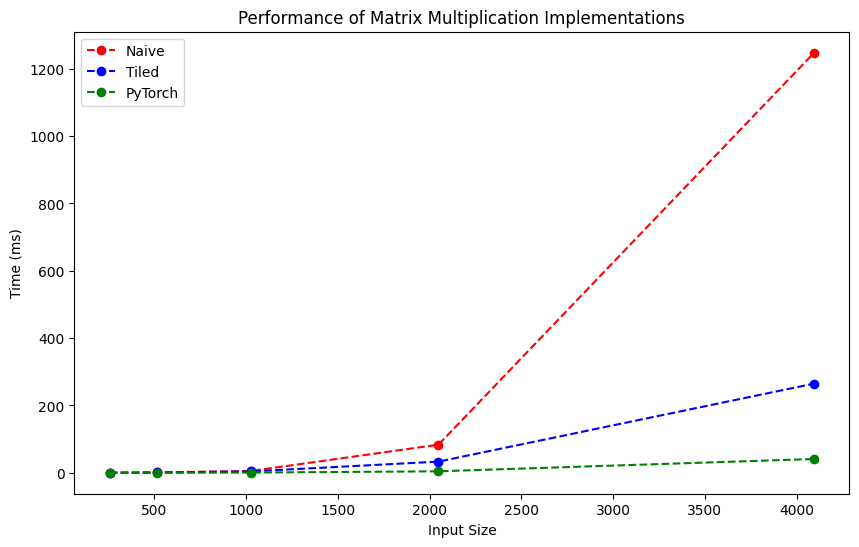

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(input_sizes, [time_dict["naive"] for time_dict in time_dict_list], label='Naive', marker='o', linestyle='--', color='red')
plt.plot(input_sizes, [time_dict["tiled"] for time_dict in time_dict_list], label='Tiled', marker='o', linestyle='--', color='blue')
plt.plot(input_sizes, [time_dict["pytorch"] for time_dict in time_dict_list], label='PyTorch', marker='o', linestyle='--', color='green')
plt.legend()
plt.xlabel('Input Size')
plt.ylabel('Time (ms)')
plt.title('Performance of Matrix Multiplication Implementations')
plt.show()

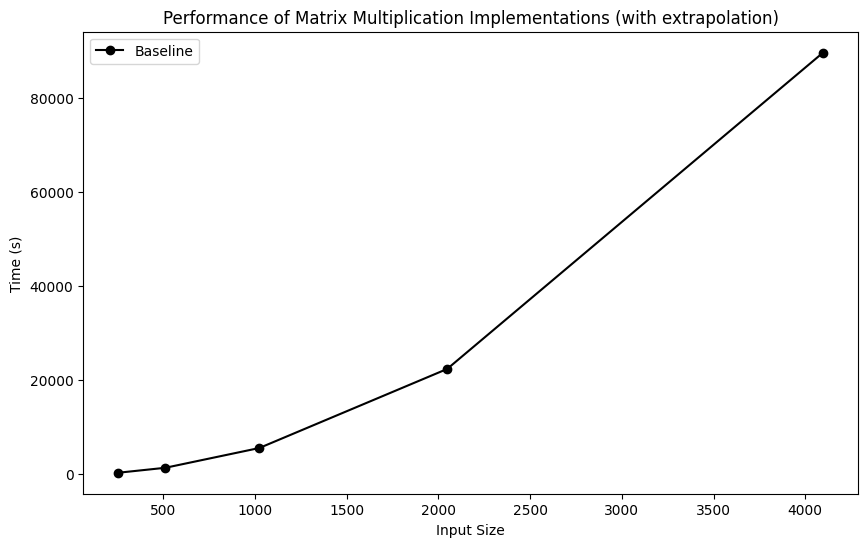

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(input_sizes, [time_dict["baseline"] for time_dict in time_dict_list], label='Baseline', marker='o', color='black')
plt.legend()
plt.xlabel('Input Size')
plt.ylabel('Time (s)')
plt.title('Performance of Matrix Multiplication Implementations (with extrapolation)')
plt.show()

## Profiling

Now we will also again run the kernels only with ncu to get DRAM data (shared and global reads)

In [20]:
def write_script_to_file(script, filename):
    with open(filename, 'w') as f:
        f.write(script)



In [21]:
write_script_to_file(cpp_matmul, 'matmul.cpp')
write_script_to_file(cuda_matmul, 'matmul_cuda.cu')

In [22]:
profile_matmul_script = """

import torch
import argparse

from torch.utils.cpp_extension import load_inline


parser = argparse.ArgumentParser(
    description="Matrix Multiplication Profiler"
)

parser.add_argument(
    "--input_size",
    type=int,
    default=256,
    help="Input size of square matrices"
)

parser.add_argument(
    "--kernel",
    type=str,
    choices=["naive", "tiled", "torch"],
    default="naive",
    help="Kernel to profile"
)

args = parser.parse_args()


def read_file(filename):
    with open(filename, "r") as f:
        return f.read()


cpp_matmul = read_file("./matmul.cpp")
cuda_matmul = read_file("./matmul_cuda.cu")


matmul_module = load_inline(
    name="matmul_v2",
    cpp_sources=cpp_matmul,
    cuda_sources=cuda_matmul,
    functions=["naive_cuda", "tiled_cuda"],
    extra_cuda_cflags=["-O3"],
    extra_cflags=["-O3"],
    verbose=False
)


N = args.input_size

A = torch.randn(
    N,
    N,
    device="cuda",
    dtype=torch.float32
)

B = torch.randn(
    N,
    N,
    device="cuda",
    dtype=torch.float32
)


# --------------------------------------------------
# Warm-up
# --------------------------------------------------

for _ in range(3):

    if args.kernel == "naive":
        C = matmul_module.naive_cuda(A, B)

    elif args.kernel == "tiled":
        C = matmul_module.tiled_cuda(A, B)

    elif args.kernel == "torch":
        C = A @ B


torch.cuda.synchronize()


# --------------------------------------------------
# Profiled execution
# --------------------------------------------------

if args.kernel == "naive":
    C = matmul_module.naive_cuda(A, B)

elif args.kernel == "tiled":
    C = matmul_module.tiled_cuda(A, B)

elif args.kernel == "torch":
    C = A @ B


torch.cuda.synchronize()

print(
    f"Finished kernel={args.kernel}, "
    f"matrix_size={N}x{N}"
)


"""




In [23]:
write_script_to_file(profile_matmul_script, 'profile_matmul_script.py')

In [24]:
!ls

matmul.cpp  matmul_cuda.cu  profile_matmul_script.py  sample_data


In [25]:
!python profile_matmul_script.py --input_size 256 --kernel tiled

Finished kernel=tiled, matrix_size=256x256


In [27]:
!ncu python profile_matmul_script.py \
    --kernel naive \
    --input_size 512

==PROF== Connected to process 69763 (/usr/bin/python3.13)
==PROF== Profiling "distribution_elementwise_grid..." - 0: 0%....50%....100% - 9 passes
==PROF== Profiling "distribution_elementwise_grid..." - 1: 0%....50%....100% - 9 passes
==PROF== Profiling "vectorized_elementwise_kernel" - 2: 0%....50%....100% - 9 passes
==PROF== Profiling "naive_cuda_matmul_kernel" - 3: 0%....50%....100% - 9 passes
==PROF== Profiling "vectorized_elementwise_kernel" - 4: 0%....50%....100% - 9 passes
==PROF== Profiling "naive_cuda_matmul_kernel" - 5: 0%....50%....100% - 9 passes
==PROF== Profiling "vectorized_elementwise_kernel" - 6: 0%....50%....100% - 9 passes
==PROF== Profiling "naive_cuda_matmul_kernel" - 7: 0%....50%....100% - 9 passes
==PROF== Profiling "vectorized_elementwise_kernel" - 8: 0%....50%....100% - 9 passes
==PROF== Profiling "naive_cuda_matmul_kernel" - 9: 0%....50%....100% - 9 passes
Finished kernel=naive, matrix_size=512x512
==PROF== Disconnected from process 69763
[69763] python3.13@127

In [29]:
!ncu --query-metrics > available_metrics.txt

In [31]:
!grep -Ei "dram.*bytes|dram.*sectors|l2.*bytes|l1tex.*global|shared.*load|shared.*store" \
available_metrics.txt

dram__bytes                                                                 Counter         byte            # of bytes accessed in DRAM                                           
dram__bytes_read                                                            Counter         byte            # of bytes read from DRAM                                             
dram__bytes_write                                                           Counter         byte            # of bytes written to DRAM                                            
dram__sectors                                                               Counter         sector          # of sectors accessed in DRAM                                         
dram__sectors_read                                                          Counter         sector          # of sectors read from DRAM                                           
dram__sectors_write                                                         Counter         sector       

In [60]:
!ncu --query-metrics | grep -E "dram__throughput|sm__throughput"

dram__throughput                                                            Throughput      %               DRAM throughput                                                       
sm__throughput                                                              Throughput      %               SM throughput assuming ideal load balancing across SMSPs              


In [81]:
!ncu --query-metrics | grep -Ei "l1tex.*shared|shared.*(ld|st|load|store|request|sector)"

l1tex__data_bank_conflicts_pipe_lsu_mem_shared                              Counter                         # of shared memory data bank conflicts generated by LDS, LD, LDSM, 3D 
l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_atom                      Counter                         # of shared memory data bank conflicts generated by ATOMS, ATOM       
l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld                        Counter                         # of shared memory data bank conflicts generated by LDS, LD, 3D       
l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_st                        Counter                         # of shared memory data bank conflicts generated by STS, ST, 3D       
l1tex__data_pipe_lsu_wavefronts                                             Counter                         # of local/global/shared + surface write wavefronts processed by      
l1tex__data_pipe_lsu_wavefronts_cmd_read                                    Counter                      

In [82]:
!ncu \
  --metrics "dram__bytes_read,dram__bytes_write,dram__throughput.avg.pct_of_peak_sustained_elapsed,l1tex__t_bytes_pipe_lsu_mem_global_op_ld,l1tex__t_requests_pipe_lsu_mem_global_op_ld,sm__sass_data_bytes_mem_shared_op_ld,sm__sass_data_bytes_mem_shared_op_st,sm__throughput.avg.pct_of_peak_sustained_elapsed" \
  --csv \
  python profile_matmul_script.py \
  --kernel torch \
  --input_size 512 \
  > torch_512.csv

In [83]:
!ncu \
  --metrics "dram__bytes_read,dram__bytes_write,dram__throughput.avg.pct_of_peak_sustained_elapsed,l1tex__t_bytes_pipe_lsu_mem_global_op_ld,l1tex__t_requests_pipe_lsu_mem_global_op_ld,sm__sass_data_bytes_mem_shared_op_ld,sm__sass_data_bytes_mem_shared_op_st,sm__throughput.avg.pct_of_peak_sustained_elapsed" \
  --csv \
  python profile_matmul_script.py \
  --kernel tiled \
  --input_size 512 \
  > tiled_512.csv

In [84]:
!ncu \
  --metrics "dram__bytes_read,dram__bytes_write,dram__throughput.avg.pct_of_peak_sustained_elapsed,l1tex__t_bytes_pipe_lsu_mem_global_op_ld,l1tex__t_requests_pipe_lsu_mem_global_op_ld,sm__sass_data_bytes_mem_shared_op_ld,sm__sass_data_bytes_mem_shared_op_st,sm__throughput.avg.pct_of_peak_sustained_elapsed" \
  --csv \
  python profile_matmul_script.py \
  --kernel naive \
  --input_size 512 \
  > naive_512.csv

In [85]:
def load_ncu(path):
    with open(path) as f:
        lines = f.readlines()

    header = next(
        i for i, line in enumerate(lines)
        if '"ID"' in line and '"Kernel Name"' in line
    )

    df = pd.read_csv(path, skiprows=header)

    df["Metric Value Numeric"] = (
        df["Metric Value"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )

    df["Metric Value Numeric"] = pd.to_numeric(
        df["Metric Value Numeric"],
        errors="coerce"
    )

    return df

In [86]:
naive = load_ncu("naive_512.csv")
tiled = load_ncu("tiled_512.csv")
torch_df = load_ncu("torch_512.csv")

In [87]:
def aggregate_metrics(df):
    return (
        df.groupby("Metric Name", as_index=False)["Metric Value Numeric"]
          .mean()
    )

naive_m = aggregate_metrics(naive)
tiled_m = aggregate_metrics(tiled)
torch_m = aggregate_metrics(torch_df)

In [89]:
def get_metric(df, contains):
    row = df[df["Metric Name"].str.contains(contains, regex=False)]
    if len(row) == 0:
        return None
    return row.iloc[0]["Metric Value Numeric"]

kernels = {
    "Naive CUDA": naive_m,
    "Tiled CUDA": tiled_m,
    "PyTorch": torch_m,
}

rows = []

for name, df in kernels.items():
    rows.append({
        "Kernel": name,

        "DRAM Read Bytes":
            get_metric(df, "dram__bytes_read.sum"),

        "DRAM Write Bytes":
            get_metric(df, "dram__bytes_write.sum"),

        "DRAM Throughput %":
            get_metric(
                df,
                "dram__throughput.avg.pct_of_peak_sustained_elapsed"
            ),

        "SM Throughput %":
            get_metric(
                df,
                "sm__throughput.avg.pct_of_peak_sustained_elapsed"
            ),

        "Global Load Requests":
            get_metric(
                df,
                "l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum"
            ),

        "Global Load Bytes":
            get_metric(
                df,
                "l1tex__t_bytes_pipe_lsu_mem_global_op_ld.sum"
            ),

        "Shared Load Bytes":
            get_metric(
                df,
                "sm__sass_data_bytes_mem_shared_op_ld.sum"
            ),

        "Shared Store Bytes":
            get_metric(
                df,
                "sm__sass_data_bytes_mem_shared_op_st.sum"
            ),
    })

comparison = pd.DataFrame(rows)

display(comparison)

,Kernel,DRAM Read Bytes,DRAM Write Bytes,DRAM Throughput %,SM Throughput %,Global Load Requests,Global Load Bytes,Shared Load Bytes,Shared Store Bytes
0,Naive CUDA,1.477923e+06,325116.800000,6.156000,45.814000,3355443.2,268435456.0,0.0,0.000000e+00
1,Tiled CUDA,1.623117e+06,343452.800000,6.674000,41.762000,209715.2,26632908.8,120795955.2,2.684355e+07
2,PyTorch,2.282043e+06,251637.333333,7.451667,63.248333,65536.0,8254048.0,17498112.0,9.098581e+06


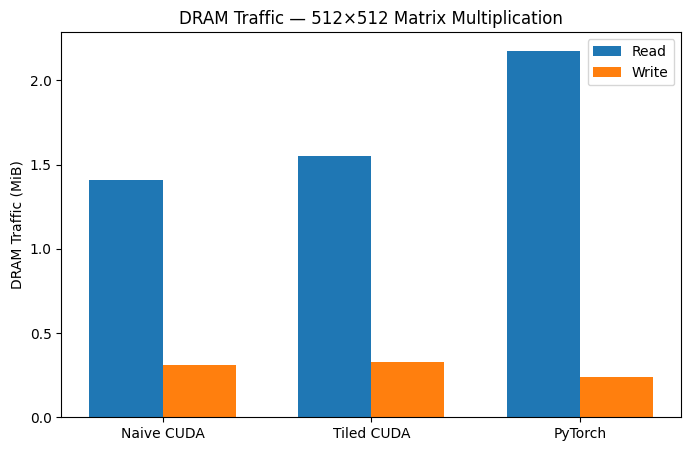

In [90]:
import numpy as np

x = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    comparison["DRAM Read Bytes"] / 1024**2,
    width,
    label="Read"
)

plt.bar(
    x + width/2,
    comparison["DRAM Write Bytes"] / 1024**2,
    width,
    label="Write"
)

plt.xticks(x, comparison["Kernel"])
plt.ylabel("DRAM Traffic (MiB)")
plt.title("DRAM Traffic — 512×512 Matrix Multiplication")
plt.legend()
plt.show()

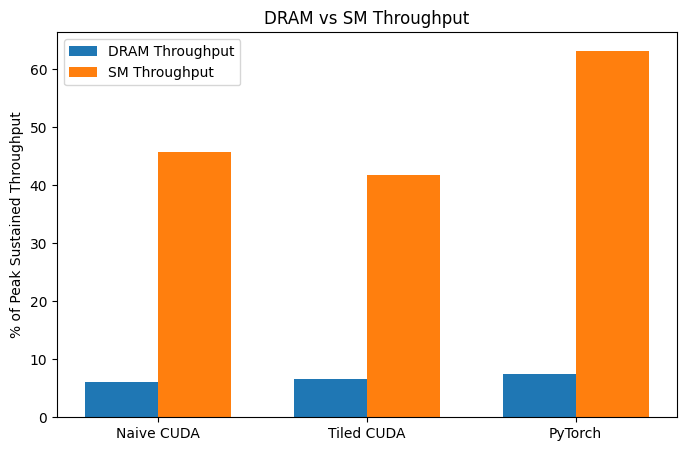

In [98]:
plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    comparison["DRAM Throughput %"],
    width,
    label="DRAM Throughput"
)

plt.bar(
    x + width/2,
    comparison["SM Throughput %"],
    width,
    label="SM Throughput"
)

plt.xticks(x, comparison["Kernel"])
plt.ylabel("% of Peak Sustained Throughput")
plt.title("DRAM vs SM Throughput")
plt.legend()
plt.show()

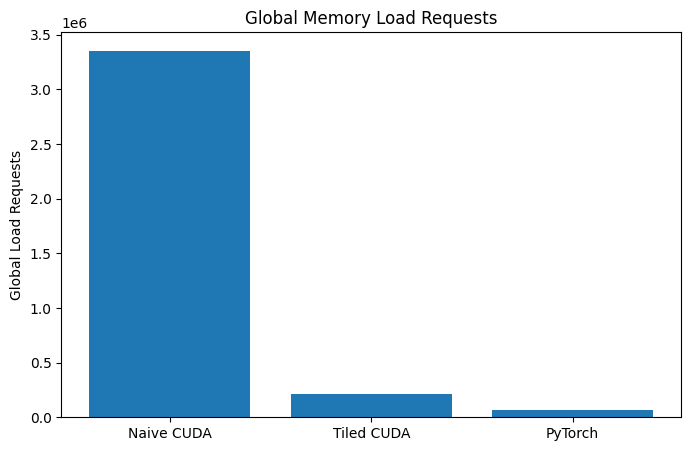

In [97]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Kernel"],
    comparison["Global Load Requests"]
)

plt.ylabel("Global Load Requests")
plt.title("Global Memory Load Requests")
plt.show()

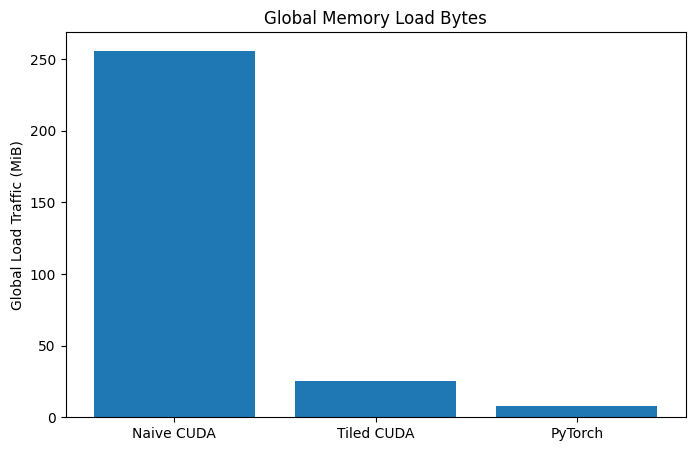

In [93]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Kernel"],
    comparison["Global Load Bytes"] / 1024**2
)

plt.ylabel("Global Load Traffic (MiB)")
plt.title("Global Memory Load Bytes")
plt.show()

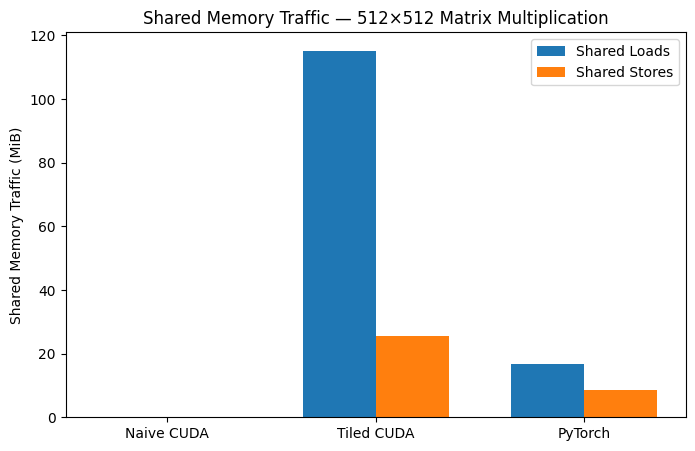

In [96]:
plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    comparison["Shared Load Bytes"] / 1024**2,
    width,
    label="Shared Loads"
)

plt.bar(
    x + width/2,
    comparison["Shared Store Bytes"] / 1024**2,
    width,
    label="Shared Stores"
)

plt.xticks(x, comparison["Kernel"])
plt.ylabel("Shared Memory Traffic (MiB)")
plt.title("Shared Memory Traffic — 512×512 Matrix Multiplication")
plt.legend()
plt.show()

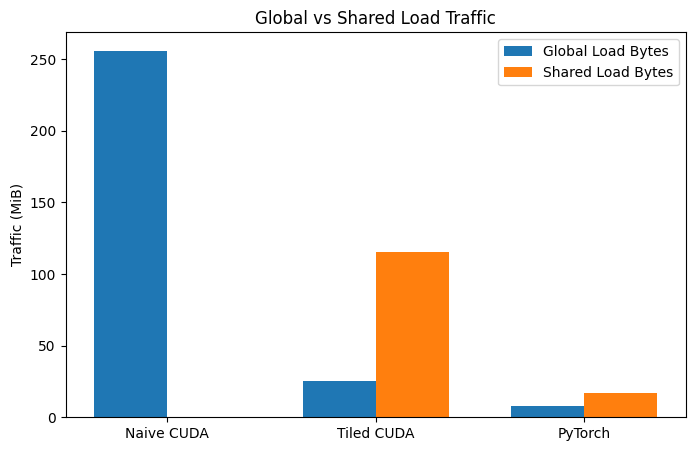

In [95]:
plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    comparison["Global Load Bytes"] / 1024**2,
    width,
    label="Global Load Bytes"
)

plt.bar(
    x + width/2,
    comparison["Shared Load Bytes"] / 1024**2,
    width,
    label="Shared Load Bytes"
)

plt.xticks(x, comparison["Kernel"])
plt.ylabel("Traffic (MiB)")
plt.title("Global vs Shared Load Traffic")
plt.legend()
plt.show()

## Observations


### 1. DRAM Traffic



The measured DRAM traffic was relatively small for all three implementations.

Approximate DRAM read traffic:

- Naive CUDA: ~1.4 MiB
- Tiled CUDA: ~1.55 MiB
- PyTorch: ~2.2 MiB

DRAM writes were approximately 0.2–0.35 MiB.

Surprisingly, the tiled kernel did **not** reduce DRAM traffic relative to the naive implementation. PyTorch also generated the largest measured DRAM read traffic despite being the most optimized implementation.



**Interpretation**

This demonstrates an important distinction:

> **Global-memory accesses are not equivalent to DRAM accesses.**

A global-memory load does not necessarily travel all the way to DRAM. The requested data may already be available in the GPU cache hierarchy.

The naive kernel generated a very large number of global-memory requests, but the earlier NCU analysis showed extremely high L2 cache hit behavior. Therefore, many redundant global loads were satisfied by cache instead of reaching DRAM.

Consequently, reducing global-memory instructions through tiling does not necessarily produce a proportional reduction in measured DRAM traffic.





### 2. DRAM vs SM Throughput



**Observation**

Approximate utilization:

| Kernel | DRAM Throughput | SM Throughput |
|---|---:|---:|
| Naive CUDA | ~6% | ~46% |
| Tiled CUDA | ~7% | ~42% |
| PyTorch | ~8% | ~63% |

All three implementations used only a relatively small fraction of peak DRAM throughput.

SM throughput was substantially higher than DRAM throughput, with PyTorch achieving the highest SM utilization.



**Interpretation**

For this 512 × 512 workload, none of the implementations appears to be saturating available DRAM bandwidth.

The PyTorch implementation achieves substantially greater SM throughput, indicating that its optimized matrix-multiplication implementation keeps the GPU's computational resources more effectively utilized.

The tiled implementation does not automatically achieve higher SM throughput than the naive implementation. Shared-memory tiling reduces redundant global-memory work, but other factors such as synchronization, instruction overhead, occupancy, scheduling, and the simplicity of the tile implementation also affect overall utilization.

Therefore:

> **Reducing memory traffic is only one component of GPU optimization.**





### 3. Global-Memory Load Requests



**Observation**

The largest difference appeared in the number of global-memory load requests.

Approximate results:

- Naive CUDA: ~3.35 million requests
- Tiled CUDA: ~0.21 million requests
- PyTorch: ~0.07 million requests

The tiled implementation therefore generated approximately **16× fewer global-memory load requests than the naive implementation**.



**Interpretation**

This result directly demonstrates the purpose of the 16 × 16 tiling strategy.

In the naive implementation, threads repeatedly request matrix elements while calculating their output values.

In the tiled implementation:

1. Threads cooperatively load portions of A and B.
2. Those values are placed into shared memory.
3. Threads repeatedly reuse those values from shared memory.
4. The block then loads the next K-dimension tile.

Therefore, one global-memory load can contribute to multiple arithmetic operations.

The observed ~16× reduction corresponds directly to the reuse enabled by the tile size.

This experimentally confirms the central idea:

> **Tiling reduces redundant global-memory accesses by loading data once and reusing it many times from shared memory.**





### 4. Global-Memory Load Bytes



**Observation**

Approximate global-load traffic:

- Naive CUDA: ~256 MiB
- Tiled CUDA: ~25 MiB
- PyTorch: ~8 MiB

The naive implementation generates dramatically more global-memory load traffic than either optimized implementation.

The tiled kernel reduces global-load traffic by roughly an order of magnitude.

PyTorch reduces it even further.



**Interpretation**

This result exposes an important difference that was hidden when looking only at DRAM traffic.

The naive kernel generates approximately 256 MiB of logical global-load traffic, but only around 1.4 MiB of measured DRAM read traffic.

Therefore, much of the requested data is being serviced before reaching DRAM.

The GPU's cache hierarchy is effectively rescuing a significant amount of the naive kernel's redundant memory activity.

This produces the seemingly paradoxical result:

> **The tiled kernel can have dramatically fewer global-memory loads while having similar or even slightly higher measured DRAM traffic.**

There is no contradiction because global-memory traffic and physical DRAM traffic measure different levels of the memory system.





### 5. Shared-Memory Traffic



**Observation**

The naive kernel shows essentially no explicit shared-memory traffic.

The tiled kernel shows approximately:

- ~115 MiB shared-memory load traffic
- ~25 MiB shared-memory store traffic

PyTorch shows approximately:

- ~17 MiB shared-memory load traffic
- ~9 MiB shared-memory store traffic



**Interpretation**

This directly exposes the mechanism implemented in the tiled CUDA kernel.

Naive CUDA:

Global memory → computation

Tiled CUDA:

Global memory → shared memory → repeated reuse → computation

The tiled kernel intentionally introduces substantial shared-memory traffic.

This is not undesirable traffic. It represents data reuse occurring in fast, programmer-managed on-chip memory rather than repeatedly requesting the same operands through the global-memory hierarchy.

Therefore:

> **The tiled kernel trades repeated global-memory accesses for repeated shared-memory accesses.**

This is exactly the behavior that shared-memory tiling was designed to produce.





### 6. Global vs Shared Load Traffic



**Observation**

The contrast between global and shared traffic clearly separates the three implementations.

Naive CUDA

- Very high global-load traffic (~256 MiB)
- Essentially zero explicit shared-memory traffic

The kernel relies heavily on repeated global-memory loads and hardware caching.

Tiled CUDA

- Global-load traffic drops dramatically (~25 MiB)
- Shared-load traffic increases dramatically (~115 MiB)

This demonstrates explicit programmer-controlled data reuse.

Instead of repeatedly requesting operands globally, the kernel loads tiles and repeatedly accesses them from shared memory.

PyTorch

- Very low global-load traffic (~8 MiB)
- Moderate shared-memory traffic (~17 MiB)
- Highest observed SM throughput (~63%)

The optimized GEMM implementation therefore goes substantially beyond the simple 16 × 16 tiling strategy used in the custom CUDA implementation.

The exact optimization strategy cannot be determined from these counters alone, but the measurements clearly show substantially different and more efficient memory/computation behavior.





### 7. Key Memory-System Insight



One of the most important lessons from this experiment is that the following quantities must not be treated as equivalent:

Global-memory instructions/requests  
↓  
Global-memory requested traffic  
↓  
Cache hierarchy  
↓  
Actual DRAM traffic

A thread issuing a global-memory load does **not** imply that DRAM must be accessed.

The request may be satisfied by cache.

Shared memory is different: it is explicitly managed on-chip storage used by the programmer to create predictable reuse within a thread block.

Therefore, a kernel can simultaneously have:

- millions of global-memory requests,
- hundreds of MiB of logical global-memory traffic,
- but only a few MiB of actual DRAM traffic.

This is exactly what was observed with the naive matrix-multiplication kernel.





### 8. Overall Comparison

Naive CUDA

- Very high global-memory load activity
- No explicit shared-memory reuse
- Hardware caches hide a significant amount of redundant memory traffic
- Moderate SM utilization

Tiled CUDA

- ~16× fewer global-load requests
- Dramatically reduced global-load traffic
- Heavy shared-memory reuse
- Similar actual DRAM traffic because caching already helped the naive implementation
- Demonstrates explicit programmer-controlled data reuse

PyTorch Optimized GEMM

- Lowest global-memory load activity
- Uses shared memory/reuse mechanisms
- Highest observed SM throughput
- Demonstrates optimization beyond the simple custom 16 × 16 tiled implementation





## Final Conclusion



Shared-memory tiling fundamentally changes **where data reuse occurs**.

The naive CUDA kernel repeatedly requests operands through the global-memory hierarchy and depends heavily on hardware caches to prevent those requests from reaching DRAM.

The tiled CUDA kernel explicitly moves reuse into shared memory. This produced approximately a 16× reduction in global-memory load requests and dramatically reduced global-load traffic while introducing substantial shared-memory traffic.

Actual DRAM traffic did not decrease proportionally because the naive implementation already benefited strongly from cache hits. This demonstrates why global-memory activity and DRAM activity must be analyzed separately.

Finally, PyTorch's optimized matrix multiplication reduced global-memory activity even further while achieving substantially greater SM throughput, demonstrating that shared-memory tiling is an important optimization step but not the endpoint of high-performance GEMM optimization.

### Core Takeaway

> **Naive CUDA repeatedly requests data globally and relies on caches to rescue the redundancy. Tiled CUDA explicitly loads data once and reuses it from shared memory. Highly optimized GEMM implementations push this principle considerably further to maximize data reuse and computational utilization.**